In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm
import os

In [2]:
base_dir = os.getcwd()
gdx_path = os.path.join(base_dir, "data", "futures", "adjusted_prices_csv", "GDX.csv")
gld_path = os.path.join(base_dir, "data", "futures", "adjusted_prices_csv", "GLD.csv")

In [3]:
gdx = pd.read_csv(gdx_path)
gld = pd.read_csv(gld_path)
#gdx = pd.read_csv(r'D:\Trading\simple_trading_system\data\futures\adjusted_prices_csv\GDX.csv')
#gld = pd.read_csv(r'D:\Trading\simple_trading_system\data\futures\adjusted_prices_csv\GLD.csv')

In [4]:
gdx = gdx[['Date', 'Adj Close']]
gld = gld[['Date', 'Adj Close']]

In [5]:
gdx.dropna(inplace=True)
gld.dropna(inplace=True)
gld['Date'] = pd.to_datetime(gld['Date'])
gdx['Date'] = pd.to_datetime(gdx['Date'])
prices = pd.merge(gld, gdx, on='Date', how='inner')
prices.rename(columns={'Adj Close_x': 'GLD', 'Adj Close_y': 'GDX'}, inplace=True)
prices.sort_values(by='Date', inplace=True)

In [6]:
model = RollingOLS(prices['GLD'], sm.add_constant(prices['GDX']), window=200)
results = model.fit()
prices['hedge_ratio'] = results.params['GDX']
prices['spread'] = prices['GLD'] - prices['hedge_ratio'] * prices['GDX']
prices['spread_mean'] = prices['spread'].rolling(200).mean()
prices['spread_std'] = prices['spread'].rolling(200).std()
prices['z_score'] = (prices['spread'] - prices['spread_mean']) / prices['spread_std']

In [7]:
prices

,Date,GLD,GDX,hedge_ratio,spread,spread_mean,spread_std,z_score
4790,2006-05-22,65.30,31.82,NaN,NaN,NaN,NaN,NaN
4789,2006-05-23,66.38,32.45,NaN,NaN,NaN,NaN,NaN
4788,2006-05-24,64.06,31.22,NaN,NaN,NaN,NaN,NaN
4787,2006-05-25,64.70,32.76,NaN,NaN,NaN,NaN,NaN
4786,2006-05-26,65.10,32.95,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
4,2025-05-30,303.60,50.65,4.805788,60.186846,81.214678,13.186226,-1.594682
3,2025-06-02,311.67,53.77,4.762177,55.607764,81.117870,13.302864,-1.917640
2,2025-06-03,308.91,53.09,4.722443,58.195482,81.037119,13.392892,-1.705504
1,2025-06-04,310.90,53.21,4.688471,61.426453,80.972141,13.456521,-1.452507


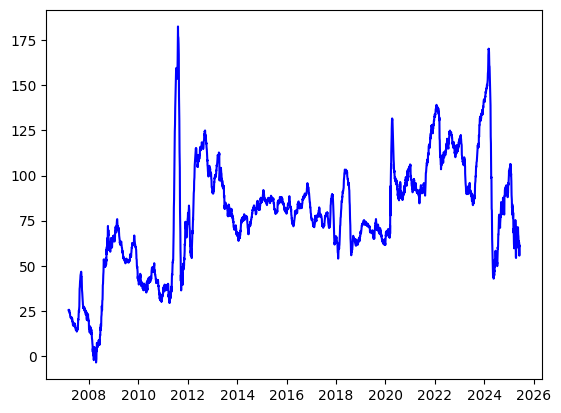

In [17]:
plt.plot(prices['Date'], prices['spread'], label='Spread', color='blue')

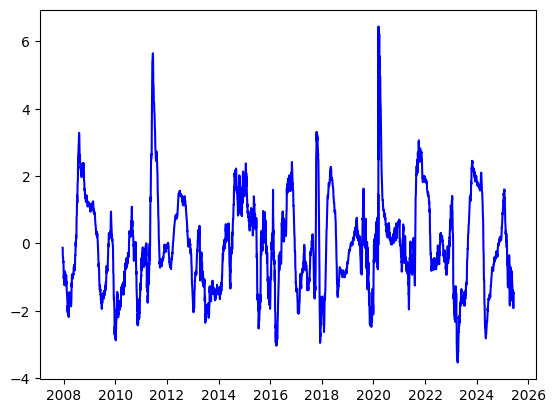

In [18]:
plt.plot(prices['Date'], prices['z_score'], label='Spread', color='blue')

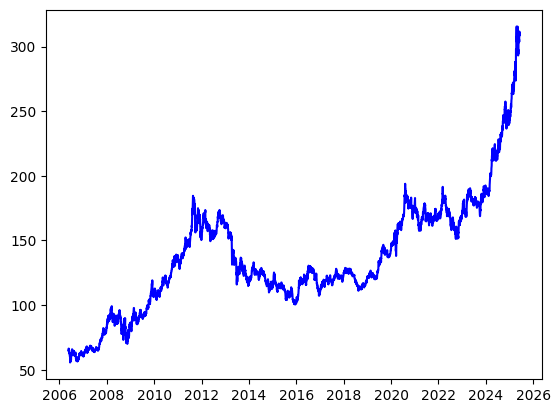

In [19]:
plt.plot(prices['Date'], prices['GLD'], label='Spread', color='blue')

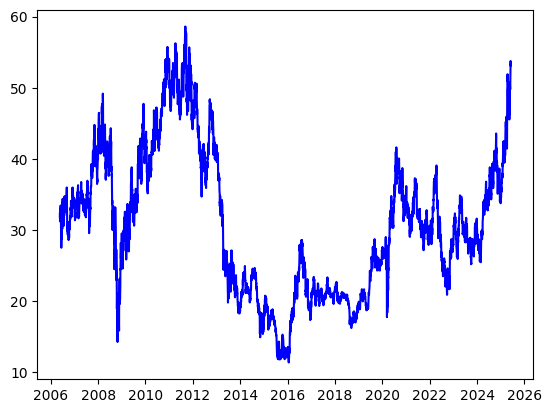

In [20]:
plt.plot(prices['Date'], prices['GDX'], label='Spread', color='blue')

In [88]:
class Position:
    def __init__(self, direction, gld_units, gdx_units, entry_price_gld, entry_price_gdx, entry_date):
        self.gld_units = gld_units
        self.gdx_units = gdx_units
        self.entry_price_gld = entry_price_gld
        self.entry_price_gdx = entry_price_gdx
        self.direction = direction
        self.entry_date = entry_date
        self.exit_date = None
        self.pnl = 0.0
        self.open = True
    
    def calculate_pnl(self,current_price_gld, current_price_gdx):  
        if self.direction == -1:   #short spread
            pnl_gld = (self.entry_price_gld - current_price_gld) * self.gld_units
            pnl_gdx = (current_price_gdx - self.entry_price_gdx) * self.gdx_units
            self.pnl = pnl_gld + pnl_gdx
        else:                #long spread 
            pnl_gld = (current_price_gld - self.entry_price_gld) * self.gld_units
            pnl_gdx = (self.entry_price_gdx - current_price_gdx) * self.gdx_units
            self.pnl = pnl_gld + pnl_gdx
            
        return self.pnl
    
    def close_position(self, date):
        self.open = False
        self.exit_date = date

    def get_pnl(self):
        return self.pnl
        

In [68]:
def goldspread_rule(z_score, entry_threshold=0.2, exit_threshold=0.3):
    if z_score > entry_threshold:
        return -1 # Short GLD, Long GDX
    elif z_score < -entry_threshold:
        return  1 # Long GLD, Short GDX
    elif z_score < exit_threshold:
        return 0 # exit position
    else:
        return -2 # hold position

In [96]:
class Portfolio:
    def __init__(self, prices,initial_capital=100000):
        self.positions = []
        self.capitial = initial_capital
        self.running_pnl = 0.0
        self.prices = prices
        self.current_position = None

    def position_size(self, current_price_gld, current_price_gdx,hedge_ratio):
        effective_unit_cost = current_price_gld + (hedge_ratio * current_price_gdx)
        gld_units = self.capitial // effective_unit_cost
        gdx_units = gld_units * hedge_ratio

        return int(gld_units), int(gdx_units)
        
    def open_position(self, direction ,gld_units, gdx_units, entry_price_gld, entry_price_gdx, date):
        if self.current_position is not None and self.current_position.open:
            raise Exception("Cannot open a new position while another is open.")
        self.current_position = Position(direction, gld_units, gdx_units, entry_price_gld, entry_price_gdx, date)
        self.positions.append(self.current_position)

    def close_position(self, current_price_gld, current_price_gdx, date):
        pnl = self.current_position.calculate_pnl(current_price_gld, current_price_gdx)
        self.running_pnl += pnl
        self.capitial += pnl
        self.current_position.close_position(date)
        self.current_position = None

    def get_average_holding(self):
        holding_periods = [(x.exit_date - x.entry_date).days for x in self.positions if isinstance(x, Position) and x.exit_date is not None]
        average_holding_period = np.mean(holding_periods) if holding_periods else 0
        return average_holding_period
    
    def calcualte_sharpe_ratio(self, risk_free_rate=0.03):
        returns = []
        holding_periods_days = []
        for pos in self.positions:
            if pos.exit_date is not None:
                pnl = pos.get_pnl()
                current_return = pnl / self.capitial
                holding_period_days = (pos.exit_date - pos.entry_date).days
                holding_periods_days.append(holding_period_days)
                returns.append(current_return)

        if len(returns) == 0:
            return 0
        
        adjusted_risk_free_rates = [(1 + risk_free_rate)**(period / 365.0) - 1 for period in holding_periods_days]
        excess_returns = np.array(returns) - np.array(adjusted_risk_free_rates)

        sharpe_ratio_per_trade = np.mean(excess_returns) / np.std(excess_returns)
        
        # 3. Annualize the Sharpe Ratio
        total_years = (self.prices['Date'].iloc[-1] - self.prices['Date'].iloc[0]).days / 365.0
        trades_per_year = len(returns) / total_years
        
        annualized_sharpe_ratio = sharpe_ratio_per_trade * np.sqrt(trades_per_year)

        return annualized_sharpe_ratio  
    
    def backtest(self):
        for i in range(800, len(self.prices)-300):
        
            current_price_gld = prices['GLD'].iloc[i]
            current_price_gdx = prices['GDX'].iloc[i]
            z_score = prices['z_score'].iloc[i]
            hedge_ratio = prices['hedge_ratio'].iloc[i]
            date = prices['Date'].iloc[i]

            signal = goldspread_rule(z_score)

            if signal == -1:  # Short GLD, Long GDX
                if self.current_position is None or not self.current_position.open:
                    gld_units, gdx_units = self.position_size(current_price_gld, current_price_gdx, hedge_ratio)
                    self.open_position(-1, gld_units, gdx_units, current_price_gld, current_price_gdx, date)
            
            elif signal == 1 :  # Long GLD, Short GD
                if self.current_position is None or not self.current_position.open:
                    gld_units, gdx_units = self.position_size(current_price_gld, current_price_gdx, hedge_ratio)
                    self.open_position(1, gld_units, gdx_units, current_price_gld, current_price_gdx, date)

            elif signal == 0:  # Exit position
                if self.current_position is not None and self.current_position.open:
                    self.close_position(current_price_gld, current_price_gdx, date)

In [97]:
test_portfolio = Portfolio(prices)
test_portfolio.backtest()

print(test_portfolio.get_average_holding())
#daily_pnl = [pos.get_pnl() for pos in test_portfolio.positions]  # Ensure get_pnl is called only on valid Position instances
#plt.plot(prices['Date'][400:400+len(daily_pnl)], daily_pnl, label='Daily PnL', color='orange')  # Match lengths
print(test_portfolio.capitial)
print(test_portfolio.calcualte_sharpe_ratio())

41.20183486238532
235267.93000000023
0.33573608053930154


Average Holding Period: 41.20183486238532


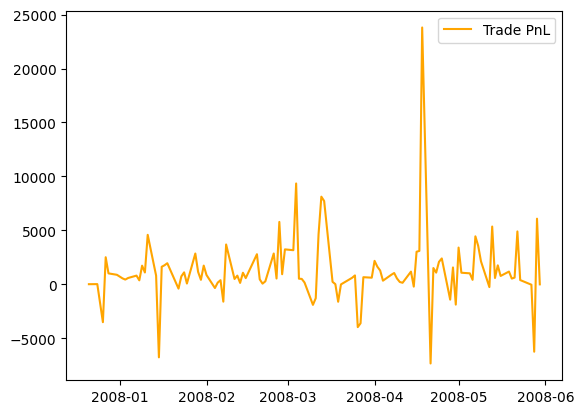

[15.31000000000222, 22.599999999999454, -3504.8199999999933, 2513.379999999999, 1016.2400000000007, 886.1499999999972, 555.5000000000016, 442.3500000000022, 589.5400000000043, 810.6200000000102, 372.8399999999983, 1731.360000000006, 1099.740000000001, 4588.320000000003, 809.7300000000064, -6762.679999999991, 1629.9200000000028, 1769.520000000004, 1958.9999999999964, -394.84000000000015, 736.419999999996, 1111.4400000000005, 75.76000000000352, 2857.800000000005, 1150.7400000000075, 420.1899999999918, 1738.3600000000006, 864.9799999999955, -339.800000000002, 162.95999999999344, 386.63000000000056, -1602.0600000000031, 3693.4599999999955, 497.98999999999154, 809.0599999999968, 134.47999999999524, 1076.299999999995, 579.2700000000059, 2793.1399999999985, 462.17000000000206, 66.28000000001327, 279.95999999999606, 2859.840000000002, 540.7600000000018, 5784.809999999994, 938.739999999992, 3241.1000000000013, 3164.3599999999897, 9347.939999999999, 524.4599999999996, 504.71999999999923, 168.599

In [ ]:
pnl = [x.get_pnl() for x in test_portfolio.positions if isinstance(x, Position)]

plt.plot(prices['Date'][400:400+len(pnl)], pnl, label='Trade PnL', color='orange')  # Match lengths
plt.legend()
plt.show()

print(pnl)


In [119]:
""" Calculate P&L at one time point using:
    position: (np) arrary [direction, GLD units, GDX units]
    previous_price: (pd) DataFrame with previous (yesturdays) prices
    current_price: (pd) DataFrame with current prices
    """

def calculate_pandl(position, previous_price, current_price):
    if position == 1: # GLD long, GDX short
        long_pnl = (current_price['GLD'] - previous_price['GLD'])* position[1]
        short_pnl = (previous_price['GDX'] - current_price['GDX']) * position[2]
        return long_pnl + short_pnl
    elif position == -1:
        long_pnl = (previous_price['GLD'] - current_price['GLD']) * position[1]
        short_pnl = (current_price['GDX'] - previous_price['GDX']) * position[2]
        return long_pnl + short_pnl
    else:
        return 0

In [120]:
def backtester(data, entry_threshold=2, exit_threshold=0.5):
    positions = []
    current_position = None
    num_units = 10
    pnl = 0.0

    for i in range(400, len(data)-1):
        current_price_gld = data['GLD'].iloc[i]
        current_price_gdx = data['GDX'].iloc[i]
        z_score = data['z_score'].iloc[i]

        if z_score > entry_threshold:
            if current_position is None:    
                gld_units = num_units
                gdx_units = gld_units * data['hedge_ratio'].iloc[i]
                current_position = Position(-1, gld_units, gdx_units,current_price_gld, current_price_gdx)
                positions.append(current_position)
            elif current_position:
                current_position.calculate_pnl(current_price_gld, current_price_gdx)
            
        elif z_score < exit_threshold and current_position is not None:
            pnl += current_position.calculate_pnl(current_price_gld, current_price_gdx)
            current_position.close_position()
            print("closed position", current_position.pnl)
            current_position = None

    return pnl


In [48]:
backtester(prices)

NameError: name 'backtester' is not defined

In [122]:
""" 
Currently we use: 
        - entry threshold to enter a short position against GDL and long GDX
        - exit threshold to exit the short position against GDL and long GDX

"""

def backtester(data, entry_threshold=2, exit_threshold=1):
    position = np.nan((len(data),4)) # position, GLD units, GDX units, PnL
    position[399,:] = np.array([0, 0, 0, 0])  # Initialize first position
    for i in range(400, len(data)-1):
        pnl = calculate_pandl(position[i-1], data['GLD'].iloc[i-1], data['GDX'].iloc[i-1])
        pnl+= position[i-1,3]  # Add previous PnL to current PnL
        if data['z_score'].iloc[i] > entry_threshold:  
            if position[i-1,0] == -1:  # If already short
                position[i,:] = np.array([-1, position[i-1,1], position[i-1,2], pnl])
            elif position[i-1,0] == 0:  # If flat
                position[i,:] = np.array([-1, data['GLD'].iloc[i], data['hedge_ratio'].iloc[i] * data['GLD'].iloc[i], pnl])
            else:  # If long
                position[i,:] = np.array([-1, ], )
            position[i,:] = 
    return position

SyntaxError: invalid syntax (3276082946.py, line 21)

In [ ]:
prices

,Date,GLD,GDX,hedge_ratio,spread,spread_mean,spread_std,z_score
4790,2006-05-22,65.30,31.82,NaN,NaN,NaN,NaN,NaN
4789,2006-05-23,66.38,32.45,NaN,NaN,NaN,NaN,NaN
4788,2006-05-24,64.06,31.22,NaN,NaN,NaN,NaN,NaN
4787,2006-05-25,64.70,32.76,NaN,NaN,NaN,NaN,NaN
4786,2006-05-26,65.10,32.95,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
4,2025-05-30,303.60,50.65,4.805788,60.186846,81.214678,13.186226,-1.594682
3,2025-06-02,311.67,53.77,4.762177,55.607764,81.117870,13.302864,-1.917640
2,2025-06-03,308.91,53.09,4.722443,58.195482,81.037119,13.392892,-1.705504
1,2025-06-04,310.90,53.21,4.688471,61.426453,80.972141,13.456521,-1.452507
